# Exploratory Data Analysis and Preprocessing
## Synthetic Health Insurance Claims Data

**Dataset:** Apex Synthetic Health Insurance Claims Fraud Detection<br>
**Source:** Kaggle<br>
**Purpose:** Understand data structure, identify patterns, and prepare data for anomaly detection models<br>

##  1. Setup and Data Loading
### 1.1 Import Libraries

In [3]:
#Data manipulation
import pandas as pd 
import numpy as np

#Visualization
import matplotlib.pyplot as plt 
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Utilities
import warnings
warnings.filterwarnings("ignore")

#Set style for better visualizations
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: '%.2f' % x)


### 1.2 Load Dataset

In [4]:
#Load the dataset
df = pd.read_csv("../data/healthcare_sample_10k.csv")
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of rows: {len(df):,}")

Dataset loaded successfully!
Shape: (10000, 10)
Number of columns: 10
Number of rows: 10,000


### 1.3 Quick Overview

In [5]:
#Display first few rows
df.head()
#Display data types and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              10000 non-null  str    
 1   patient_id            10000 non-null  str    
 2   provider_npi          10000 non-null  str    
 3   date_of_service       10000 non-null  str    
 4   icd10_diagnosis_code  10000 non-null  str    
 5   cpt_procedure_code    10000 non-null  int64  
 6   billed_amount         10000 non-null  float64
 7   claim_status          10000 non-null  str    
 8   is_anomaly            10000 non-null  int64  
 9   anomaly_type          394 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 1.7 MB


## 2. Data Exploration
### 2.1 Data Summary

In [6]:
# Statistical summary of numeric columns
df.describe()

,cpt_procedure_code,billed_amount,is_anomaly
count,10000.00,10000.00,10000.00
mean,85512.24,330.50,0.04
std,20674.71,776.08,0.19
min,36415.00,25.00,0.00
25%,85025.00,66.43,0.00
50%,99213.00,157.71,0.00
75%,99284.00,365.32,0.00
max,99285.00,44886.64,1.00


In [7]:
#Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

claim_id: 10000 unique values
patient_id: 9803 unique values
provider_npi: 7193 unique values
date_of_service: 10000 unique values
icd10_diagnosis_code: 8 unique values
claim_status: 3 unique values
anomaly_type: 2 unique values


### 2.2 Missing Values Analysis

Columns with missing values: 1
anomaly_type    9606
dtype: int64


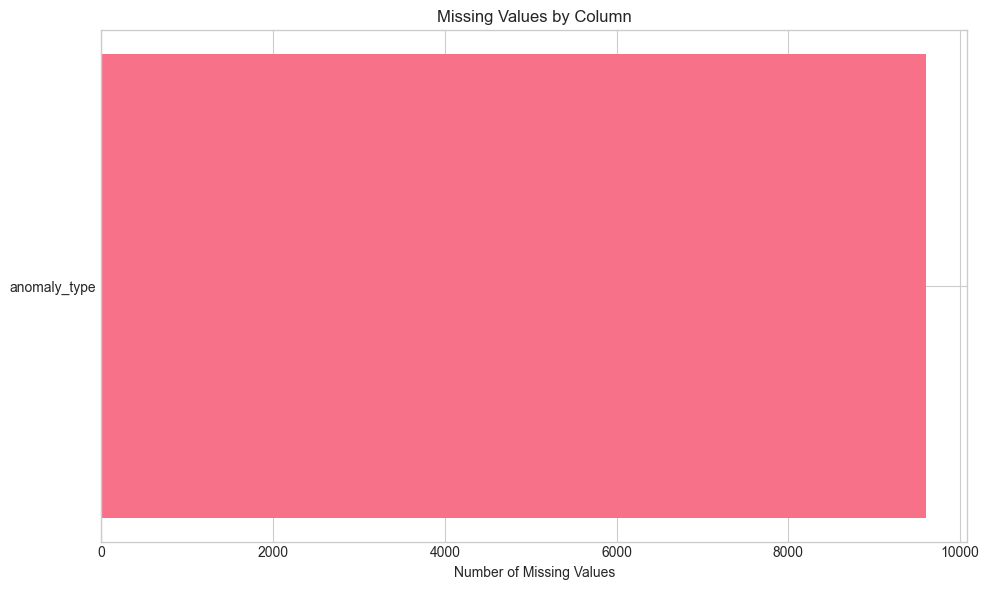

In [9]:
#check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    print(f"Columns with missing values: {len(missing_values)}")
    print(missing_values)

    #visualize missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values.index, missing_values.values)
    plt.xlabel("Number of Missing Values")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found in the dataset.")

### 2.3 Target Variable Analysis


Fraud Distribution:
is_anomaly
0    9606
1     394
Name: count, dtype: int64

Fraud Percentage: 3.94%


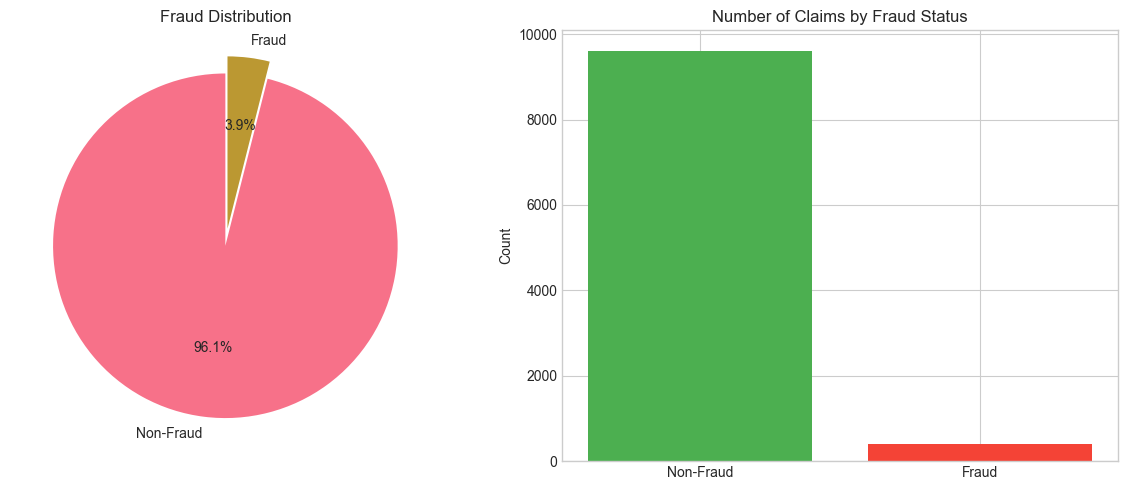

In [12]:
# Distribution of fraudulent vs non-fraudulent claims
fraud_distribution = df['is_anomaly'].value_counts()
print(f"Fraud Distribution:\n{fraud_distribution}")
print(f"\nFraud Percentage: {df['is_anomaly'].mean() * 100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(fraud_distribution.values, labels=['Non-Fraud', 'Fraud'], 
            autopct='%1.1f%%', explode=(0, 0.1), startangle=90)
axes[0].set_title('Fraud Distribution')

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[1].bar(['Non-Fraud', 'Fraud'], fraud_distribution.values, color=colors)
axes[1].set_ylabel('Count')
axes[1].set_title('Number of Claims by Fraud Status')

plt.tight_layout()
plt.show()


## 3. Univariate Analysis

### 3.1 Numeric Features Analysis
#### 3.1.1 Billed Amount

In [19]:
# Histogram
axes[0].hist(df['billed_amount'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['billed_amount'].mean(), color='red', linestyle='--', 
               label=f'Mean: {df["billed_amount"].mean():.2f}')
axes[0].axvline(df['billed_amount'].median(), color='blue', linestyle='--', 
               label=f'Median: {df["billed_amount"].median():.2f}')
axes[0].set_xlabel('Billed Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Billed Amount')
axes[0].legend()

# Box plot
box = axes[1].boxplot(df['billed_amount'], vert=True, patch_artist=True, showfliers=False)
box['boxes'][0].set_facecolor('#3498db')
axes[1].set_ylabel('Billed Amount')
axes[1].set_title('Box Plot of Billed Amount')

plt.tight_layout()
plt.show()

# Summary statistics
print("Billed Amount Statistics:")
print(f"  Mean: {df['billed_amount'].mean():.2f}")
print(f"  Median: {df['billed_amount'].median():.2f}")
print(f"  Std: {df['billed_amount'].std():.2f}")
print(f"  Min: {df['billed_amount'].min():.2f}")
print(f"  Max: {df['billed_amount'].max():.2f}")
print(f"  Skewness: {df['billed_amount'].skew():.2f}")

<Figure size 640x480 with 0 Axes>

Billed Amount Statistics:
  Mean: 330.50
  Median: 157.71
  Std: 776.08
  Min: 25.00
  Max: 44886.64
  Skewness: 25.05


#### 3.1.2 Billed Amount by Anomaly Status

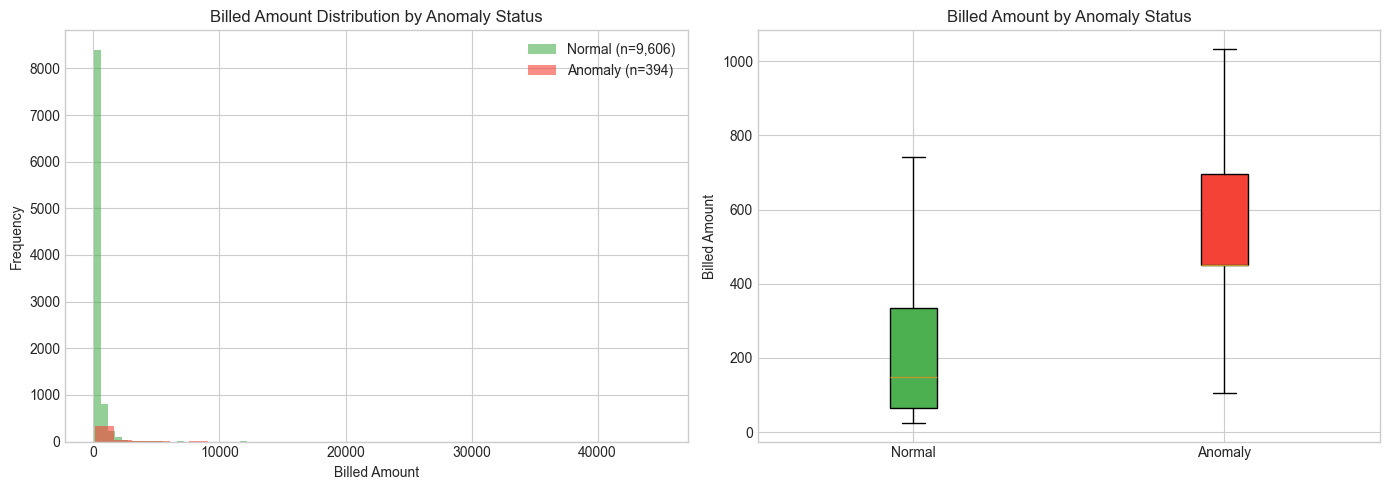


Normal:
  Mean: 302.51
  Median: 148.39
  Count: 9,606

Anomaly:
  Mean: 1012.87
  Median: 450.00
  Count: 394


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by anomaly status
for status, color, label in zip([0, 1], ['#4CAF50', '#F44336'], ['Normal', 'Anomaly']):
    subset = df[df['is_anomaly'] == status]['billed_amount']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f"{label} (n={len(subset):,})", color=color)
axes[0].set_xlabel('Billed Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Billed Amount Distribution by Anomaly Status')
axes[0].legend()

# Box plot by anomaly status
data_to_plot = [
    df[df['is_anomaly'] == 0]['billed_amount'],
    df[df['is_anomaly'] == 1]['billed_amount']
]
bp = axes[1].boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_ylabel('Billed Amount')
axes[1].set_title('Billed Amount by Anomaly Status')

plt.tight_layout()
plt.show()

# Statistics by anomaly status
for status, label in [(0, 'Normal'), (1, 'Anomaly')]:
    subset = df[df['is_anomaly'] == status]['billed_amount']
    print(f"\n{label}:")
    print(f"  Mean: {subset.mean():.2f}")
    print(f"  Median: {subset.median():.2f}")
    print(f"  Count: {len(subset):,}")

#### 3.1.3 CPT Procedure Code Distribution

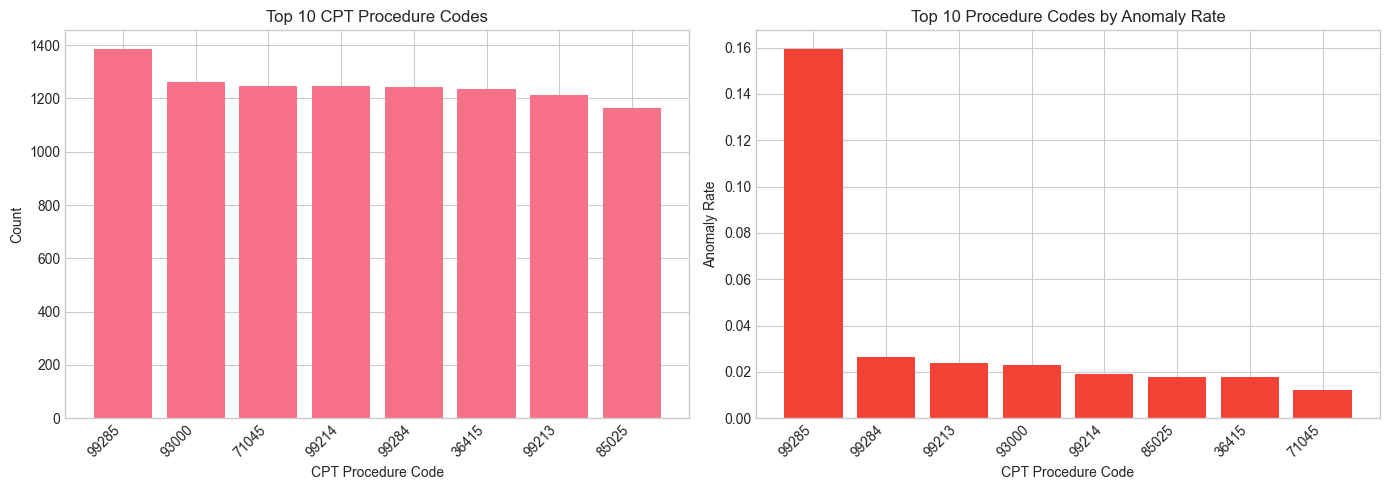

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 procedure codes
top_procedures = df['cpt_procedure_code'].value_counts().head(10)

# Bar chart
axes[0].bar(top_procedures.index.astype(str), top_procedures.values)
axes[0].set_xlabel('CPT Procedure Code')
axes[0].set_ylabel('Count')
axes[0].set_title('Top 10 CPT Procedure Codes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Fraud rate by procedure code
proc_anomaly_rate = df.groupby('cpt_procedure_code')['is_anomaly'].mean().sort_values(ascending=False).head(10)
axes[1].bar(proc_anomaly_rate.index.astype(str), proc_anomaly_rate.values, color='#F44336')
axes[1].set_xlabel('CPT Procedure Code')
axes[1].set_ylabel('Anomaly Rate')
axes[1].set_title('Top 10 Procedure Codes by Anomaly Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 3.2 Categorical Features Analysis
#### 3.2.1 Claim Status

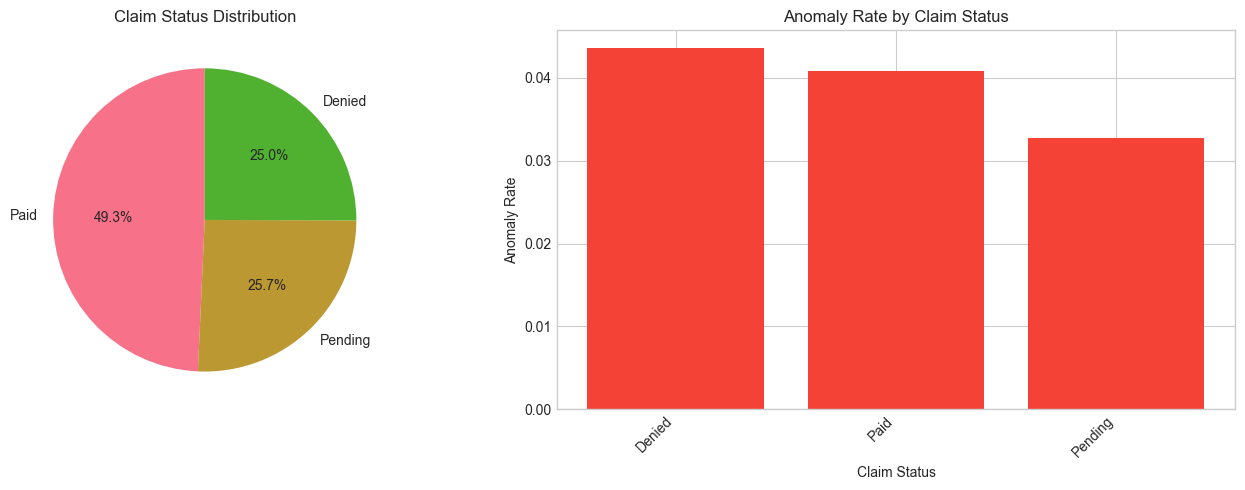

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of claim status
status_counts = df['claim_status'].value_counts()

# Pie chart
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Claim Status Distribution')

# Anomaly rate by claim status
status_anomaly_rate = df.groupby('claim_status')['is_anomaly'].mean().sort_values(ascending=False)
axes[1].bar(status_anomaly_rate.index, status_anomaly_rate.values, color='#F44336')
axes[1].set_xlabel('Claim Status')
axes[1].set_ylabel('Anomaly Rate')
axes[1].set_title('Anomaly Rate by Claim Status')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### 3.2.2 ICD-10 Diagnosis Codes

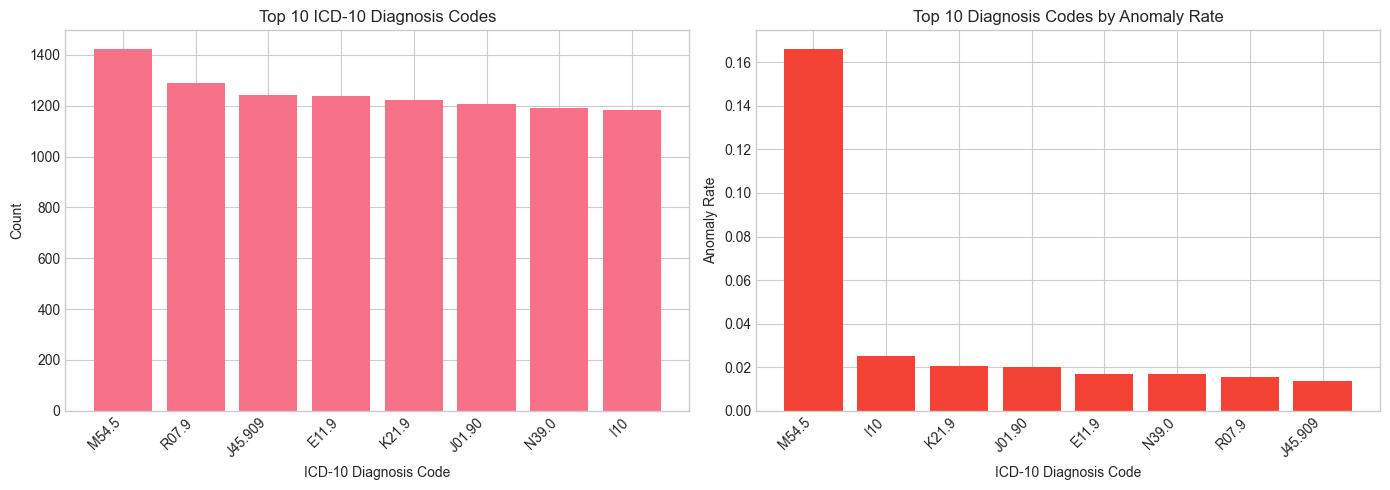

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 diagnosis codes
top_diagnosis = df['icd10_diagnosis_code'].value_counts().head(10)

# Bar chart
axes[0].bar(top_diagnosis.index, top_diagnosis.values)
axes[0].set_xlabel('ICD-10 Diagnosis Code')
axes[0].set_ylabel('Count')
axes[0].set_title('Top 10 ICD-10 Diagnosis Codes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Anomaly rate by diagnosis code
diag_anomaly_rate = df.groupby('icd10_diagnosis_code')['is_anomaly'].mean().sort_values(ascending=False).head(10)
axes[1].bar(diag_anomaly_rate.index, diag_anomaly_rate.values, color='#F44336')
axes[1].set_xlabel('ICD-10 Diagnosis Code')
axes[1].set_ylabel('Anomaly Rate')
axes[1].set_title('Top 10 Diagnosis Codes by Anomaly Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 4. Bivariate Analysis
#### 4.1 Correlation Analysis

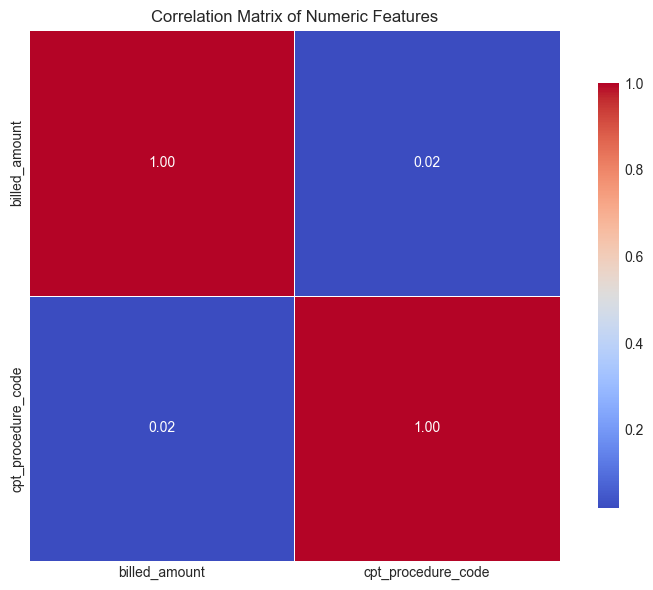

In [25]:
# Select numeric columns for correlation
numeric_cols = ['billed_amount', 'cpt_procedure_code']
correlation_matrix = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

#### 4.2 Billed Amount vs. Anomaly Rate

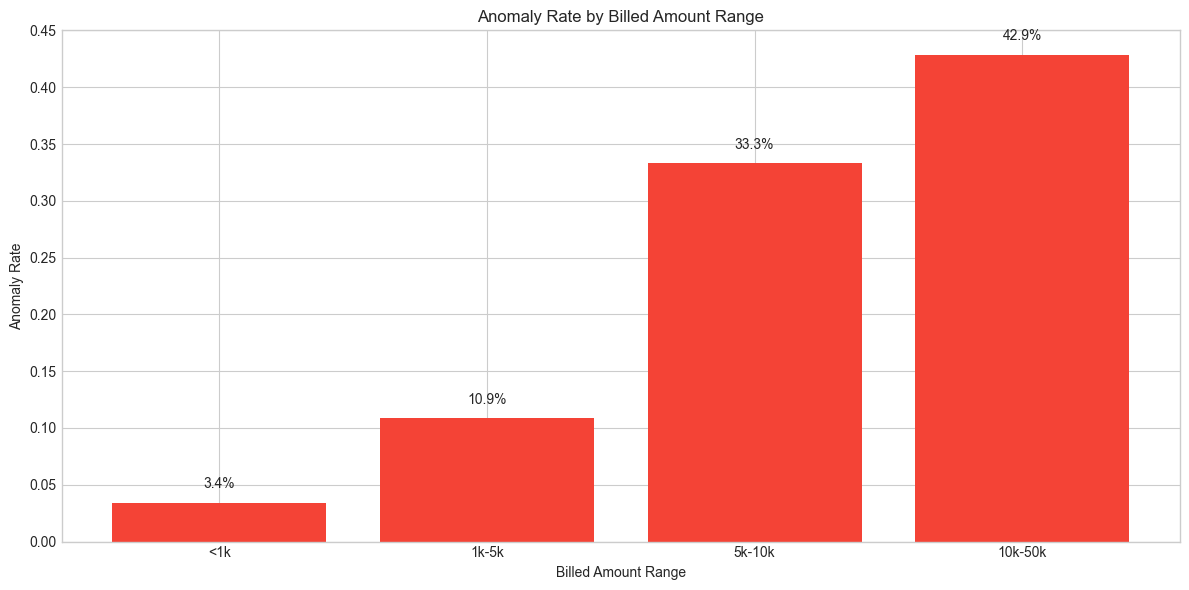

In [26]:
# Bucket billed amounts and calculate anomaly rate
bins = [0, 1000, 5000, 10000, 50000, 100000, 500000, float('inf')]
labels = ['<1k', '1k-5k', '5k-10k', '10k-50k', '50k-100k', '100k-500k', '>500k']
df['amount_bucket'] = pd.cut(df['billed_amount'], bins=bins, labels=labels)

anomaly_by_amount = df.groupby('amount_bucket', observed=False)['is_anomaly'].mean()

plt.figure(figsize=(12, 6))
bars = plt.bar(anomaly_by_amount.index, anomaly_by_amount.values, color='#F44336')
plt.xlabel('Billed Amount Range')
plt.ylabel('Anomaly Rate')
plt.title('Anomaly Rate by Billed Amount Range')
for bar, value in zip(bars, anomaly_by_amount.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.1%}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

#### 4.3 CPT Procedure Code vs. Anomaly

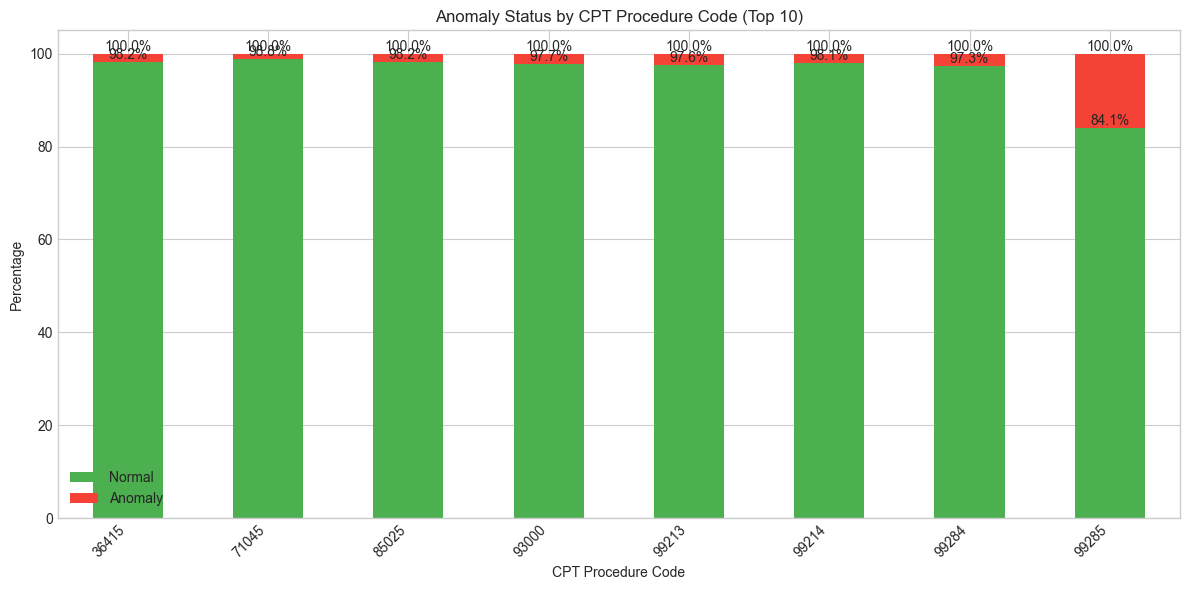

In [27]:
# Cross tabulation of top procedures
top_procedures = df['cpt_procedure_code'].value_counts().head(10).index
proc_data = df[df['cpt_procedure_code'].isin(top_procedures)]

proc_anomaly = pd.crosstab(proc_data['cpt_procedure_code'], proc_data['is_anomaly'], 
                           normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
proc_anomaly.plot(kind='bar', stacked=True, ax=ax, color=['#4CAF50', '#F44336'])
ax.set_xlabel('CPT Procedure Code')
ax.set_ylabel('Percentage')
ax.set_title('Anomaly Status by CPT Procedure Code (Top 10)')
ax.legend(['Normal', 'Anomaly'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### 4.4 Claim Status vs. Anomaly

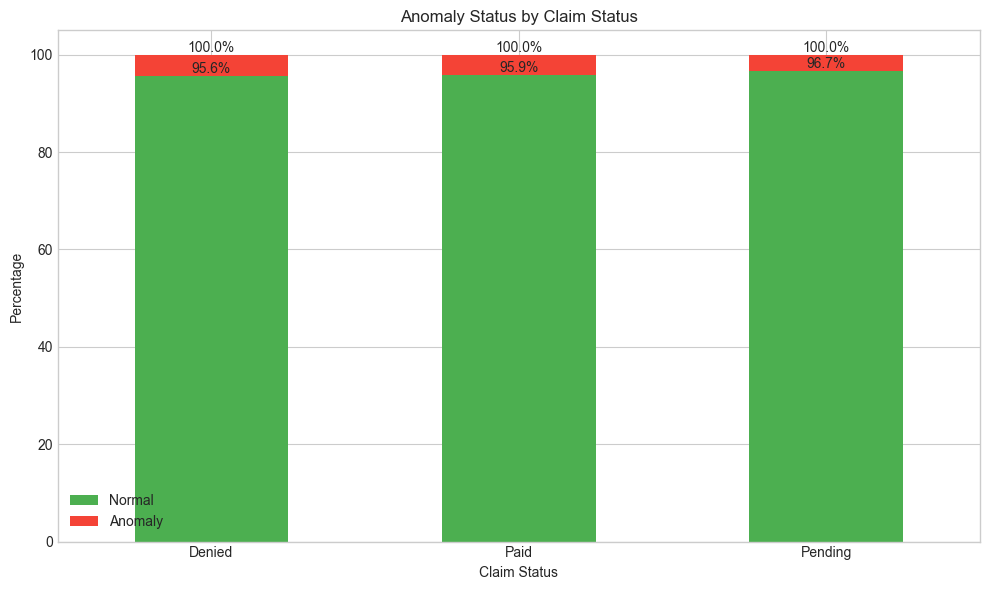

Chi-square test: chi2=4.3940, p=1.1114e-01


In [28]:
status_anomaly = pd.crosstab(df['claim_status'], df['is_anomaly'], 
                             normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
status_anomaly.plot(kind='bar', stacked=True, ax=ax, color=['#4CAF50', '#F44336'])
ax.set_xlabel('Claim Status')
ax.set_ylabel('Percentage')
ax.set_title('Anomaly Status by Claim Status')
ax.legend(['Normal', 'Anomaly'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['claim_status'], df['is_anomaly'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test: chi2={chi2:.4f}, p={p:.4e}")

### 5. Anomaly Pattern Analysis
#### 5.1 Provider Anomaly Rate Distribution

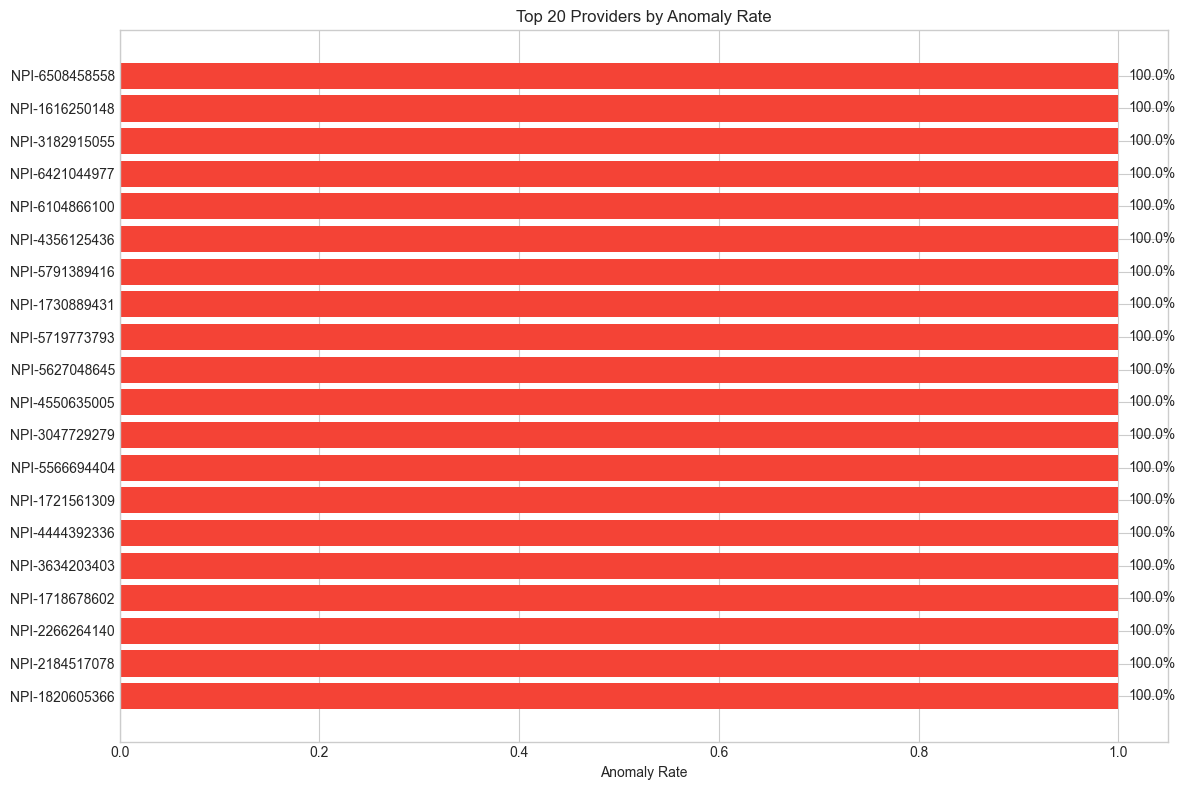

In [29]:
# Calculate anomaly rate by provider
provider_anomaly = df.groupby('provider_npi').agg({
    'is_anomaly': ['mean', 'count']
}).reset_index()
provider_anomaly.columns = ['provider_npi', 'anomaly_rate', 'claim_count']
provider_anomaly = provider_anomaly.sort_values('anomaly_rate', ascending=False)

# Top 20 providers with highest anomaly rate
top_20_providers = provider_anomaly.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_20_providers['provider_npi'], top_20_providers['anomaly_rate'], color='#F44336')
ax.set_xlabel('Anomaly Rate')
ax.set_title('Top 20 Providers by Anomaly Rate')
for bar, rate in zip(bars, top_20_providers['anomaly_rate']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1%}', va='center')

plt.tight_layout()
plt.show()

#### 5.2 Patient Anomaly Rate Distribution

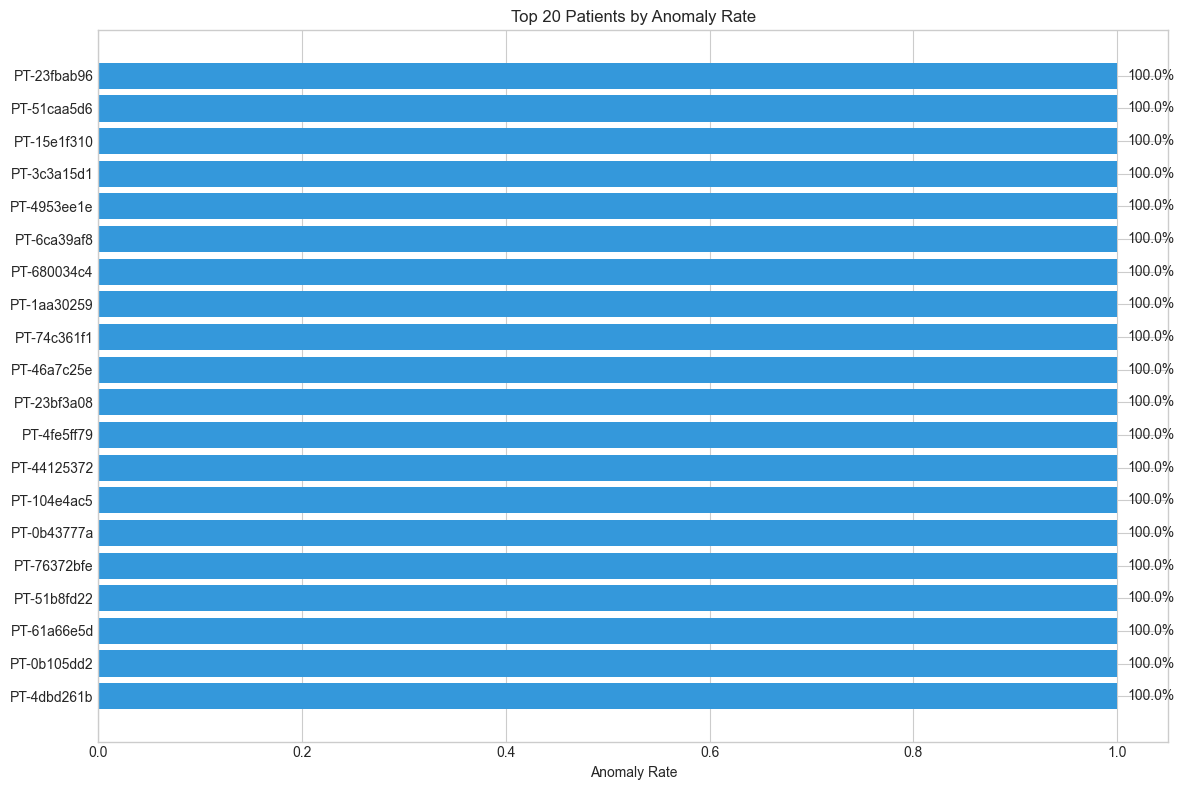

In [30]:
# Calculate anomaly rate by patient
patient_anomaly = df.groupby('patient_id').agg({
    'is_anomaly': ['mean', 'count']
}).reset_index()
patient_anomaly.columns = ['patient_id', 'anomaly_rate', 'claim_count']
patient_anomaly = patient_anomaly.sort_values('anomaly_rate', ascending=False)

# Top 20 patients with highest anomaly rate
top_20_patients = patient_anomaly.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_20_patients['patient_id'], top_20_patients['anomaly_rate'], color='#3498db')
ax.set_xlabel('Anomaly Rate')
ax.set_title('Top 20 Patients by Anomaly Rate')
for bar, rate in zip(bars, top_20_patients['anomaly_rate']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1%}', va='center')

plt.tight_layout()
plt.show()

### 6. Preprocessing

#### 6.1 Date Feature Extraction

In [31]:
def extract_date_features(df):
    """Extract features from date_of_service."""
    df_processed = df.copy()
    
    # Convert to datetime
    df_processed['date_of_service'] = pd.to_datetime(df_processed['date_of_service'])
    
    # Extract features
    df_processed['year'] = df_processed['date_of_service'].dt.year
    df_processed['month'] = df_processed['date_of_service'].dt.month
    df_processed['day_of_week'] = df_processed['date_of_service'].dt.dayofweek
    df_processed['day_of_month'] = df_processed['date_of_service'].dt.day
    df_processed['quarter'] = df_processed['date_of_service'].dt.quarter
    
    # Drop original date column
    df_processed = df_processed.drop(columns=['date_of_service'])
    
    return df_processed

#### 6.2 Frequency Encoding

In [32]:
def frequency_encode(df, columns):
    """Apply frequency encoding to categorical columns."""
    df_processed = df.copy()
    
    for col in columns:
        if col in df_processed.columns:
            freq_map = df_processed[col].value_counts(normalize=True)
            df_processed[f'{col}_freq'] = df_processed[col].map(freq_map)
            df_processed = df_processed.drop(columns=[col])
    
    return df_processed

#### 6.3 Provider Aggregates

In [33]:
def add_provider_aggregates(df):
    """Add provider-level aggregate features."""
    df_processed = df.copy()
    
    provider_agg = df.groupby('provider_npi').agg({
        'billed_amount': ['mean', 'std', 'count']
    }).reset_index()
    provider_agg.columns = ['provider_npi', 'provider_mean', 'provider_std', 'provider_volume']
    
    df_processed = df_processed.merge(provider_agg, on='provider_npi', how='left')
    
    return df_processed